In [4]:
from jax_unirep import get_reps
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import manifold
from sklearn.decomposition import PCA 

In [5]:
pdf_df = pd.read_csv('PatDf-ArtGox-2d.csv')
patg_df = pd.read_csv('PatG-2d.csv')

In [6]:
pdf_df.rename(columns={'conversion':'het_conversion', 'tot_ions':'het_tot_ions'},inplace=True)
#pdf_df.head()

In [7]:
patg_df.rename(columns={'conversion':'cyc_conversion',
                        'tot_ions':'cyc_tot_ions', 
                        'L(tot)_x':'L(tot)_cyc',
                        'L(tot)_y':'L(tot)_het'},inplace=True)
#patg_df.head()

In [8]:
assay_data = patg_df.merge(pdf_df, on='peptide')
assay_data.drop(assay_data.columns[0], axis=1, inplace=True)
assay_data.rename(columns={'L(tot)_x':'L(tot)_cyc',
                        'L(tot)_y':'L(tot)_het'},inplace=True)
assay_data.head()

,peptide,L(m+1)_x,L(m+2)_x,L(m+3)_x,C(m+1),C(m+2),C(m+3),L(tot)_cyc,C(tot),cyc_conversion,...,LHO(m+1),LHO(m+2),LHO(m+3),L(tot)_het,LHR(tot),LHO(tot),het_conversion,het_tot_ions,well_y,unfiltered_conversion_y
0,DVQAFTAPAYDG,7531874.0,19668994.0,58639.0,90305.0,69820.0,2580.0,27259507.0,162705.0,0.593333,...,2817.0,80600.0,89533.0,110916.0,86745.0,172950.0,0.000000,370611.0,A1,70.072124
1,GYLKWTAPAYDG,1461095.0,24657199.0,446022.0,535403.0,546919.0,8236.0,26564316.0,1090558.0,3.943457,...,3658.0,50541.0,669252.0,16377285.0,679909.0,723451.0,7.892627,17780645.0,A2,7.892627
2,GAEWRTAPAYDG,1017100.0,22715978.0,545006.0,62197.0,262824.0,2020.0,24278084.0,327041.0,1.329158,...,1810.0,38112.0,80646.0,17123402.0,687608.0,120568.0,4.506999,17931578.0,A3,4.506999
3,IDFVKTAPAYDG,2002792.0,39992257.0,950171.0,132742.0,167436.0,3157.0,42945220.0,303335.0,0.701376,...,889.0,23042.0,57374.0,4160535.0,292604.0,81305.0,0.000000,4534444.0,A4,8.245972
4,WLYKDTAPAYDG,1185543.0,33413060.0,800418.0,600039.0,748721.0,5307.0,35399021.0,1354067.0,3.684226,...,2142.0,58570.0,35620.0,21980669.0,1347575.0,96332.0,6.164069,23424576.0,A5,6.164069


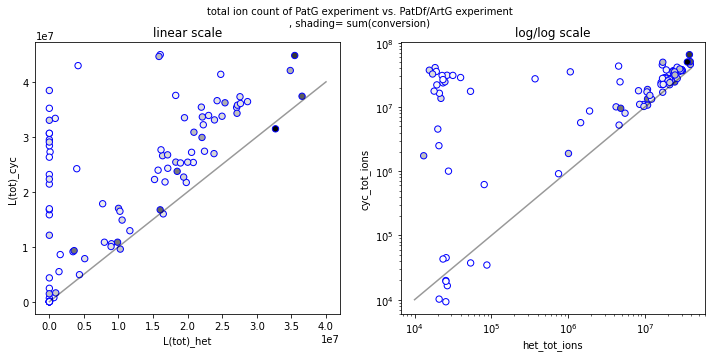

In [13]:
fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(12,5))


x = np.array(range(10000, int(4*10e6),1000))
assay_data.plot(x='L(tot)_het',y='L(tot)_cyc', kind='scatter',
          color=assay_data.loc[:,['cyc_conversion','het_conversion']].sum(axis=1),
          #color=np.log(assay_data.loc[:,['cyc_conversion','het_conversion']].sum(axis=1)),
          edgecolor='b', s=40, ax=ax[0])
ax[0].plot(x,x, color='k', alpha=0.4)


assay_data.plot(x='het_tot_ions',y='cyc_tot_ions', kind='scatter',
          color=assay_data.loc[:,['cyc_conversion','het_conversion']].sum(axis=1),
          #color=np.log(assay_data.loc[:,['cyc_conversion','het_conversion']].sum(axis=1)),
          edgecolor='b', s=40, ax=ax[1])
ax[1].plot(x,x, color='k', alpha=0.4)
plt.yscale('log')
plt.xscale('log')
fig.suptitle('total ion count of PatG experiment vs. PatDf/ArtG experiment\n, shading= sum(conversion)', fontsize=10)
ax[0].title.set_text('linear scale')
ax[1].title.set_text('log/log scale')

In [15]:
# unirep encoding
pep_seqs = [i[:5] for i in assay_data['peptide']]
h_avg, h_final, c_final = get_reps(pep_seqs)
#h_avg=h_avg.T-h_avg.mean(axis=1)
#h_avg=h_avg.T

In [16]:
tsne = manifold.TSNE(n_components=2, random_state=42)
peptide_rep = tsne.fit_transform(h_avg)
pca = PCA(n_components=2, random_state=42)
peptide_pca = pca.fit_transform(h_avg)

assay_data['tsne1'], assay_data['tsne2'] = peptide_rep[:,0], peptide_rep[:,1]
assay_data['pca1'], assay_data['pca2'] = peptide_pca[:,0], peptide_pca[:,1]

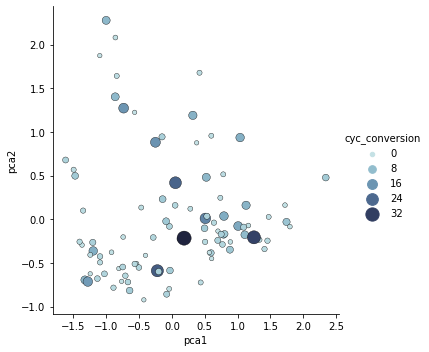

In [17]:
cmap = sns.cubehelix_palette(rot=-.2, as_cmap=True)
g = sns.relplot(
    data=assay_data,
    x="pca1", y="pca2",
    hue="cyc_conversion", size="cyc_conversion",
    palette=cmap, sizes=(20, 200), edgecolor='k'
)


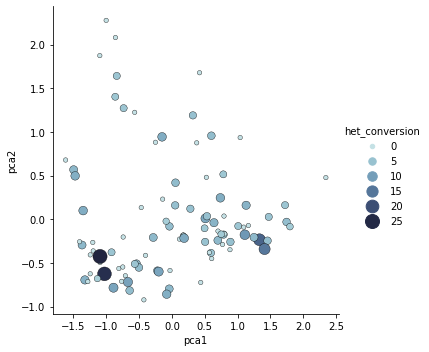

In [18]:
g = sns.relplot(
    data=assay_data,
    x="pca1", y="pca2",
    hue="het_conversion", size="het_conversion",
    palette=cmap, sizes=(20, 200), edgecolor='k'
)

# compare to old unirep distribution

In [19]:
path='/home/debonaa1/'
data = np.load(path+'/peptide_design/encoding/unirep_5mer_lib.npy')
orig_peptides = np.load(path+'/peptide_design/analysis/original_peptides.npy')
peptides = np.load(path+'/peptide_design/220510_5mer_library.npy')
orig_lib = np.load(path+'/peptide_design/analysis/unirep_orig_lib.npy')
pagg_lib = np.load(path+'/peptide_design/analysis/unirep_pagg_lib.npy')
pagg_pepseqs = np.load(path+'/peptide_design/analysis/pagg_lib.npy')
peptides = np.array([i[:5] for i in peptides]) # cut off constant region

n = round(data.shape[1])
df = pd.DataFrame(data[:, :n], index=peptides, columns = ['f'+str(i+1) for i in range(n)])

orig_df = pd.DataFrame(orig_lib, index=orig_peptides, columns = ['f'+str(i+1) for i in range(n)])
pagg_df = pd.DataFrame(pagg_lib, index=pagg_pepseqs, columns = ['f'+str(i+1) for i in range(n)])

df = df.loc[:, (df != 0).any(axis=0)]
df.head()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f1891,f1892,f1893,f1894,f1895,f1896,f1897,f1898,f1899,f1900
GADEF,0.088081,0.009338,-0.065617,0.095007,-0.019542,0.123355,-0.478922,0.081878,-0.103119,0.340690,...,0.081366,0.206757,-0.042708,0.092970,0.096515,0.086592,0.128984,0.075844,0.100289,0.147611
GADEY,0.087717,0.001923,-0.064906,0.094970,-0.018008,0.120416,-0.486670,0.082191,-0.103004,0.364526,...,0.081988,0.213068,-0.034552,0.093551,0.097330,0.083450,0.110797,0.076784,0.100077,0.153797
GADEW,0.087417,0.010377,-0.064905,0.095069,-0.025019,0.118051,-0.539491,0.082061,-0.103094,0.357155,...,0.081070,0.217500,-0.058845,0.093839,0.097736,0.083797,0.133911,0.072035,0.104962,0.160443
GAEDF,0.088011,0.014842,-0.066400,0.095073,-0.023149,0.108661,-0.511065,0.082422,-0.103102,0.394067,...,0.080354,0.173559,-0.023201,0.093363,0.094061,0.083529,0.136344,0.069250,0.100708,0.149032
GAEDY,0.087580,0.007398,-0.065931,0.095051,-0.023436,0.106679,-0.521790,0.082775,-0.102975,0.426781,...,0.080429,0.187575,-0.024757,0.093796,0.094250,0.080417,0.116422,0.066809,0.098368,0.153544


In [20]:
from sklearn.preprocessing import StandardScaler
all_pep = pd.concat([df, orig_df, pagg_df])

#scaler = StandardScaler()
#scaler.fit(all_pep)

#all_pep = scaler.transform(all_pep)

df = pd.DataFrame(df, index=peptides, columns = ['f'+str(i+1) for i in range(n)])

orig_df = pd.DataFrame(orig_lib, index=orig_peptides, columns = ['f'+str(i+1) for i in range(n)])

pagg_df = pd.DataFrame(pagg_lib, index=pagg_pepseqs, columns = ['f'+str(i+1) for i in range(n)])

# Dimensionality reduction and KMedoid clustering
The medoids are thought to be representative picks for the testing library

In [21]:
pca2 = PCA()
pca2.fit(df)
X_transform = pca2.transform(df)
print(X_transform.shape)
print(orig_lib.shape)
print(pagg_lib.shape)

(211320, 1900)
(80, 1900)
(120, 1900)


In [22]:
#try pca of concatenated peptide libraries
#all_pep = pd.concat([df, orig_df, pagg_df])
#pca = PCA()
#pca.fit(all_pep)
#X_transform = pca.transform(all_pep)

In [23]:
h_avg_encoding = pca2.transform(h_avg)
assay_data['pca1'], assay_data['pca2'] = h_avg_encoding[:,0], h_avg_encoding[:,1]

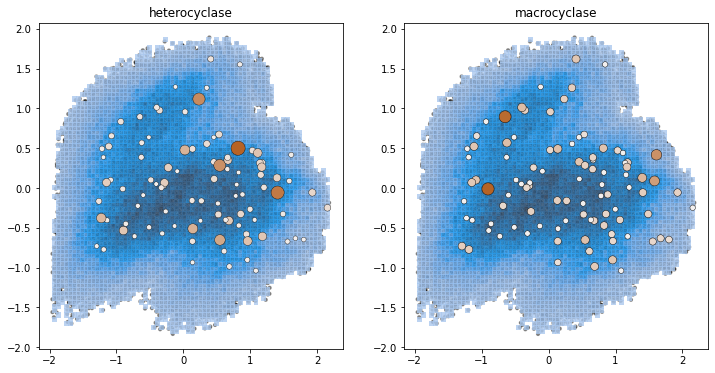

In [24]:
# visually inspect the diversity of the generated library in the unirep space
xx, yy = 0, 1

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
#cmap = sns.cubehelix_palette(start=2, as_cmap=True)
#cmap = sns.color_palette("flare", as_cmap=True)
cmap = sns.light_palette("xkcd:copper", 8, as_cmap=True)


# lay down whole library
for ax in axs:
    sns.scatterplot(x=X_transform[:, xx], y=X_transform[:, yy], alpha=0.5, 
                    color='k', size=0.1, legend=False, ax=ax)
    sns.histplot(x=X_transform[:, xx], y=X_transform[:, yy], bins=70, alpha=0.8, ax=ax)


# plot library with cyclase conversion
g = sns.scatterplot(x=h_avg_encoding[:, xx],
                y=h_avg_encoding[:, yy],
                #color=assay_data['cyc_conversion'],
                hue=assay_data['cyc_conversion'],
                edgecolor='k', legend=False,
                alpha=1, ax=axs[0],
                size=assay_data['cyc_conversion'],
               palette=cmap, sizes=(20, 200))

# plot library with heterocyclase conversion
sns.scatterplot(x=h_avg_encoding[:, xx],
                y=h_avg_encoding[:, yy],
                #color=assay_data['het_conversion'],
                 hue=assay_data['het_conversion'],
                edgecolor='k', legend=False,
                alpha=1, ax=axs[1],
                size=assay_data['het_conversion'],
               palette=cmap, sizes=(30, 150))

axs[0].set_title('heterocyclase')
axs[1].set_title('macrocyclase')

plt.show()

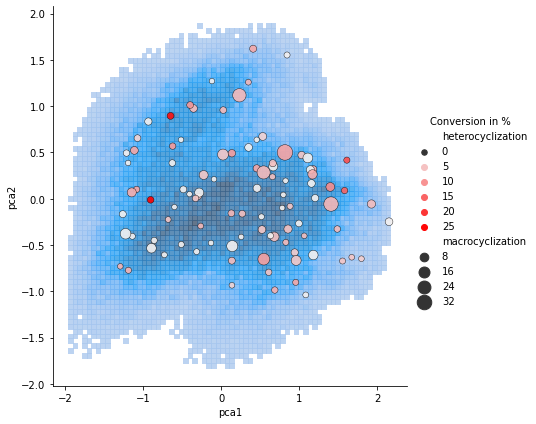

In [25]:
#cmap = sns.cubehelix_palette(rot=-0.2, as_cmap=True)
cmap = sns.light_palette("xkcd:copper", 8, as_cmap=True)
cmap = sns.light_palette("red",as_cmap=True)
assay_data['heterocyclization'] = assay_data['het_conversion'] 
assay_data['macrocyclization'] = assay_data['cyc_conversion']

g = sns.FacetGrid(assay_data, height=6)
g.map(sns.histplot, x=X_transform[:, xx], y=X_transform[:, yy], bins=70, alpha=0.8)
g.map(sns.scatterplot, x='pca1',y='pca2', data=assay_data, 
      size='macrocyclization', sizes=(30,240),
      hue='heterocyclization', palette=cmap, 
      edgecolor='k', alpha=0.9)
g.add_legend()
g._legend.set_title('Conversion in %')